In [4]:
import argparse
import yaml
from multiprocessing import cpu_count
import torch.multiprocessing as mp

import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Repo-specific imports
# -------------------------------------------------------------------
# import sys 
# print(sys.path)
from src.globals import REPO_ROOT

from tokamark.tools.utils import get_device
from tokamark.data_split import get_train_test_val_shots
from tokamark.tasks import get_task_config, get_task_metadata
from tokamark.data import (
    initialize_MAST_dataset
)


# from src.cnn_utils import (
#     cnn_training_collate_fn,
#     create_cnn_architecture,
#     loop_for_cnn_training,
#     cnn_evaluation_per_shot,
#     cnn_save_traces_per_shot,
# )

# Set device
device = get_device()
# print(f"Using device: {device}\n")

In [13]:
print(f"Number of available CPU cores: {cpu_count()}\n")
mp.set_start_method("spawn", force=True)

# -------------------------------------------------------------------
# Argument parsing
# -------------------------------------------------------------------
parser = argparse.ArgumentParser()
parser.add_argument(
    "--task",
    type=str,
    default="task_4-5",
    help="The name of the task available in the benchmark",
)
parser.add_argument(
    "--config_cnn",
    type=str,
    default="/config_cnn_batch_8_workers_2_lr_0001_D_16.yaml",
    help="Path to the model YAML config file",
)
args, _ = parser.parse_known_args()

# Load Task YAML config
config_task = get_task_config(args.task)    

# Load CNN YAML config
with open(REPO_ROOT + args.config_cnn, "r") as f:
    config_cnn = yaml.safe_load(f)


Number of available CPU cores: 76



In [14]:
# -------------------------------------------------------------------
# Initialize task-specific metadata
# -------------------------------------------------------------------

dict_task_metadata = get_task_metadata(
    config_task,
    verbose=False
)

In [40]:
config_task

{'task_name': 'task_4-5',
 'sources_and_signals': {'input_name': [['magnetics', 'flux_loop_flux'],
   ['magnetics', 'b_field_pol_probe_ccbv_field'],
   ['magnetics', 'b_field_pol_probe_obr_field'],
   ['magnetics', 'b_field_pol_probe_obv_field'],
   ['magnetics', 'b_field_tor_probe_saddle_voltage'],
   ['pf_active', 'coil_current'],
   ['pf_active', 'solenoid_current'],
   ['summary', 'ip'],
   ['interferometer', 'n_e_line'],
   ['spectrometer_visible', 'filter_spectrometer_dalpha_voltage'],
   ['soft_x_rays', 'horizontal_cam_lower'],
   ['soft_x_rays', 'horizontal_cam_upper'],
   ['magnetics', 'b_field_tor_probe_cc_field'],
   ['magnetics', 'b_field_pol_probe_omv_voltage']],
  'actuator_name': [['pulse_schedule', 'i_plasma'],
   ['pulse_schedule', 'n_e_line'],
   ['summary', 'power_nbi'],
   ['gas_injection', 'total_injected']],
  'output_name': [['magnetics', 'b_field_tor_probe_cc_field'],
   ['magnetics', 'b_field_pol_probe_omv_voltage']]},
 'task_window_segmenter': {'input_keys': [

In [41]:
# -------------------------------------------------------------------
# Initialize MAST datasets
# -------------------------------------------------------------------

train_shots_, test_shots_, val_shots_ = get_train_test_val_shots(
    max_index=config_cnn["subset_of_shots"]
)

local_flag = config_cnn["local"]

train_MAST_dataset = initialize_MAST_dataset( 
    config_task,
    train_shots_,
    local_flag = local_flag,
    use_std_scaling = True,
    return_incomplete_shots=True
)
print("len(train_MAST_dataset) is ", len(train_MAST_dataset))

val_MAST_dataset = initialize_MAST_dataset( 
    config_task,
    val_shots_,
    local_flag = local_flag,
    use_std_scaling = True,
    return_incomplete_shots=True
)

test_MAST_dataset = initialize_MAST_dataset( 
    config_task,
    test_shots_,
    local_flag = local_flag,
    use_std_scaling = False,
    return_incomplete_shots=True
)


len(train_MAST_dataset) is  9259


In [42]:
def get_idx(MAST_dataset, shot_id):
    return(MAST_dataset.shots_list.index(shot_id))

new
new


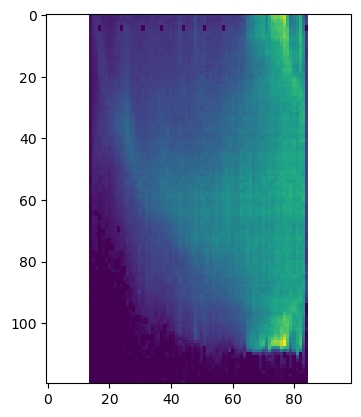

In [6]:
shot_idx = get_idx(test_MAST_dataset, 30428)
# shot_idx = get_idx(train_MAST_dataset, 29562)
var = 'thomson_scattering-n_e'
data = test_MAST_dataset[shot_idx][var]
# plt.plot( data['values'].T )
plt.imshow( data['values'])


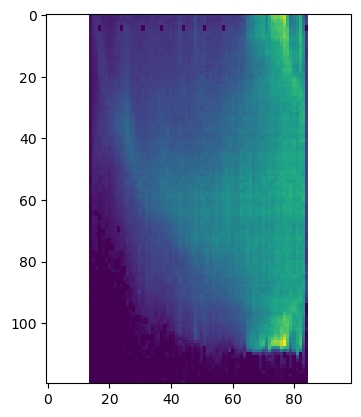

In [13]:
shot_idx = get_idx(test_MAST_dataset, 30428)
# shot_idx = get_idx(train_MAST_dataset, 29562)
var = 'thomson_scattering-n_e'
data = test_MAST_dataset[shot_idx][var]
# plt.plot( data['values'].T )
plt.imshow( data['values'])


In [25]:
data['values'].T[:100].shape

(100, 18)

In [39]:
50000/7

7142.857142857143

In [42]:
import numpy as np

np.unique(data['values'][0])

array([-0.00289917, -0.00274658, -0.00259399, -0.00244141, -0.00228882,
       -0.00213623, -0.00198364, -0.00183105, -0.00167847, -0.00152588,
       -0.00137329, -0.0012207 , -0.00106812, -0.00091553, -0.00076294,
       -0.00061035, -0.00045776, -0.00030518, -0.00015259,  0.        ,
        0.00015259,  0.00030518,  0.00045776,  0.00061035,  0.00076294,
        0.00091553,  0.0012207 ,  0.00137329,  0.00152588,  0.00167847,
        0.00183105,  0.00198364,         nan])

In [20]:
data['time'][1]-data['time'][0]

2.000000000002e-06

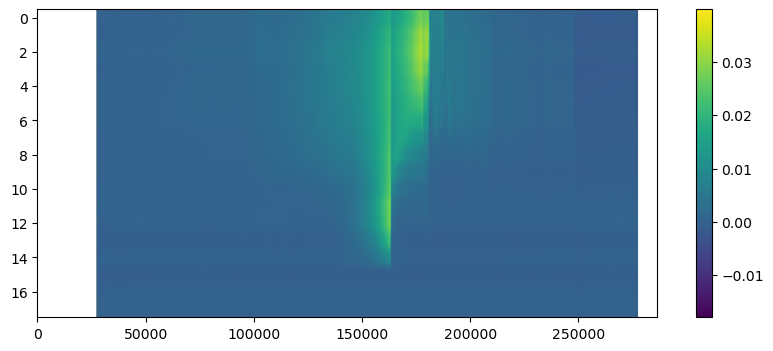

In [18]:
# shot_idx = get_idx(train_MAST_dataset, 29562)
shot_idx = 0
var = 'soft_x_rays-horizontal_cam_upper'
data = test_MAST_dataset[shot_idx][var]

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))  # width, height in inches

plt.imshow( data['values'].T[:].T, aspect='auto')
plt.colorbar()

plt.show()

In [11]:
data

NameError: name 'data' is not defined

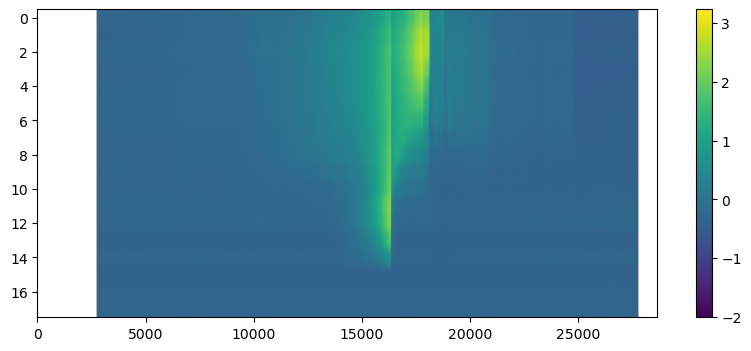

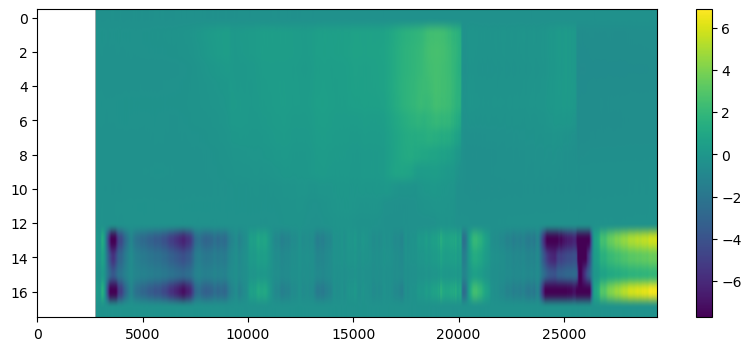

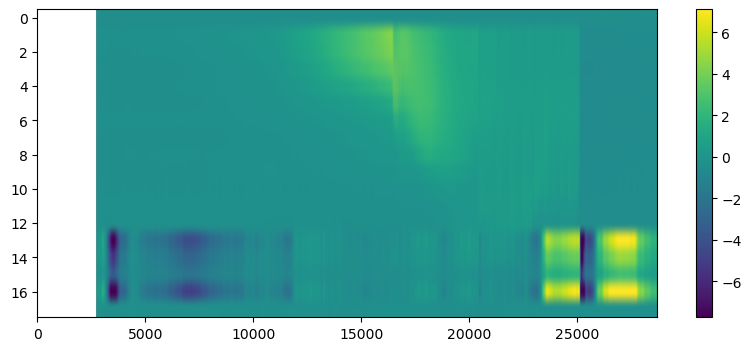

KeyboardInterrupt: 

In [17]:
test_MAST_dataset = initialize_MAST_dataset( 
    config_task,
    test_shots_,
    local_flag = local_flag,
    use_std_scaling = True,
    return_incomplete_shots=True
)

# shot_idx = get_idx(train_MAST_dataset, 29562)

for shot_idx in range(0, 10):

    var = 'soft_x_rays-horizontal_cam_upper'
    data = test_MAST_dataset[shot_idx][var]

    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 4))  # width, height in inches

    plt.imshow( data['values'].T[:].T, aspect='auto')
    plt.colorbar()

    plt.show()

In [4]:
import pickle 

metadata_path = '/home/ir-rous1/rds/rds-ukaea-ap002-mOlK9qn0PlQ/ir-rous1/output/cnn-baseline/fairmast-data-preprocessing/src/tokamark/metadata/dict_metadata.pkl'
with open(metadata_path, "rb") as f:  # 'rb' = read binary
    dict_metadata = pickle.load(f)

In [6]:
dict_metadata[var].keys()

dict_keys(['dt', 'values_shape', 'mean', 'std'])

In [8]:
for var in dict_metadata.keys():
    print(f"\n{var}")
    print(dict_metadata[var]['dt'])


magnetics-flux_loop_flux
0.0002

magnetics-b_field_pol_probe_ccbv_field
0.0002

magnetics-b_field_pol_probe_obr_field
0.0002

magnetics-b_field_pol_probe_obv_field
0.0002

magnetics-b_field_tor_probe_saddle_voltage
2e-05

magnetics-b_field_tor_probe_cc_field
2e-06

magnetics-b_field_pol_probe_omv_voltage
2e-06

pf_active-coil_voltage
0.00025

pf_active-coil_current
0.00025

pf_active-solenoid_current
0.00025

pulse_schedule-i_plasma
0.00025

pulse_schedule-n_e_line
0.00025

interferometer-n_e_line
0.00025

summary-power_nbi
0.00025

summary-ip
0.00025

gas_injection-total_injected
0.00025

equilibrium-psi
0.005

equilibrium-elongation
0.005

equilibrium-elongation_axis
0.005

equilibrium-triangularity_upper
0.005

equilibrium-triangularity_lower
0.005

equilibrium-lcfs_r
0.005

equilibrium-lcfs_z
0.005

equilibrium-x_point_r
0.005

equilibrium-x_point_z
0.005

equilibrium-minor_radius
0.005

equilibrium-magnetic_axis_r
0.005

equilibrium-magnetic_axis_z
0.005

equilibrium-q95
0.005

e

In [9]:
1/2e-06


500000.0

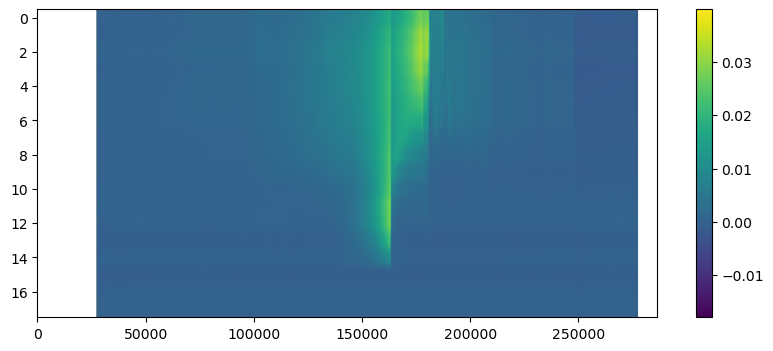

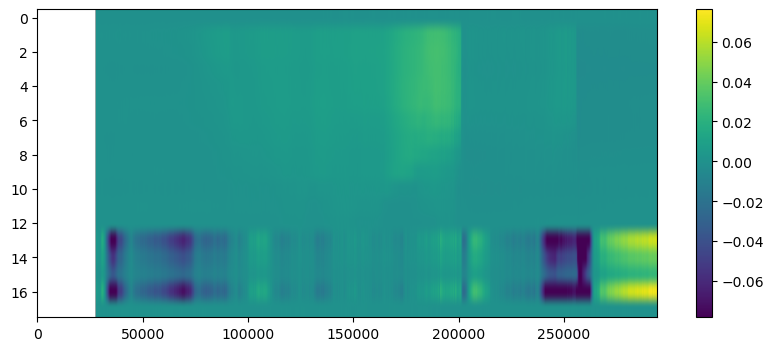

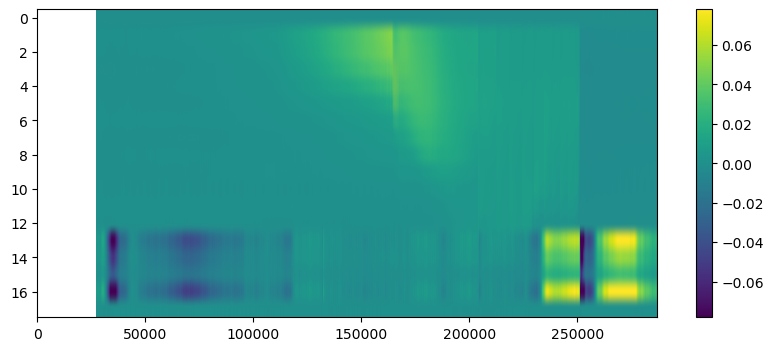

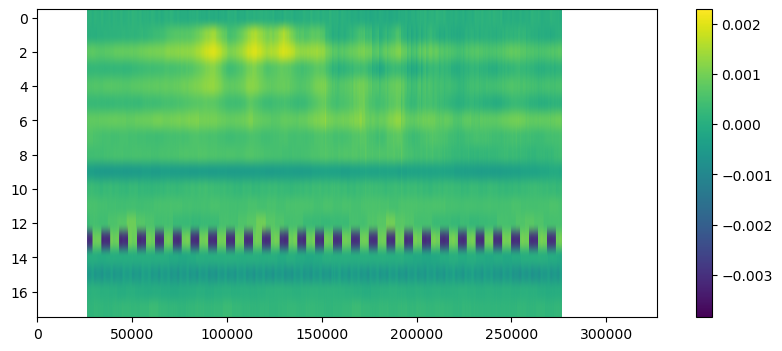

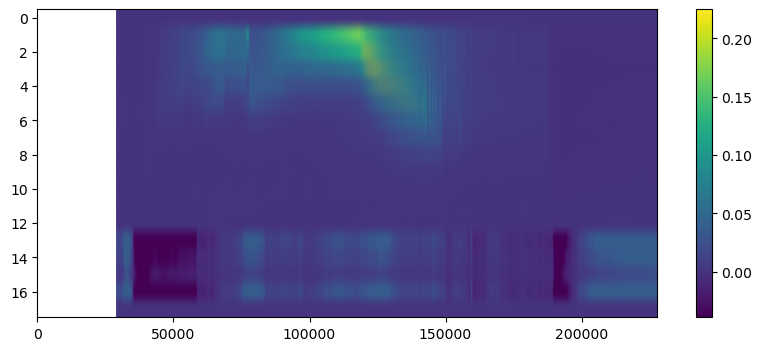

KeyboardInterrupt: 

In [62]:
# shot_idx = get_idx(train_MAST_dataset, 29562)

test_MAST_dataset = initialize_MAST_dataset( 
    config_task,
    test_shots_,
    local_flag = local_flag,
    use_std_scaling = False,
    return_incomplete_shots=True
)


for shot_idx in range(0, 10):

    var = 'soft_x_rays-horizontal_cam_upper'
    data = test_MAST_dataset[shot_idx][var]

    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 4))  # width, height in inches

    plt.imshow( data['values'].T[:].T, aspect='auto')
    plt.colorbar()

    plt.show()

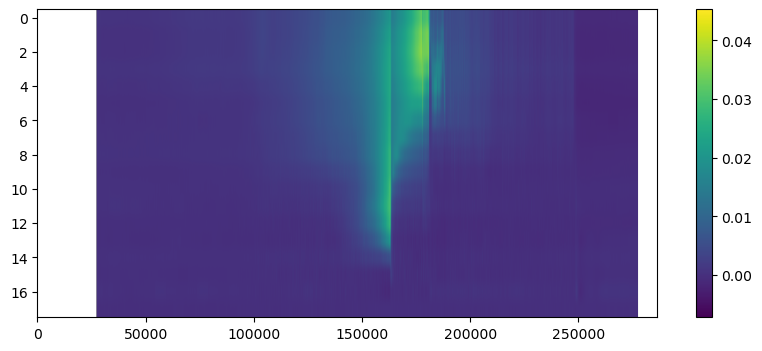

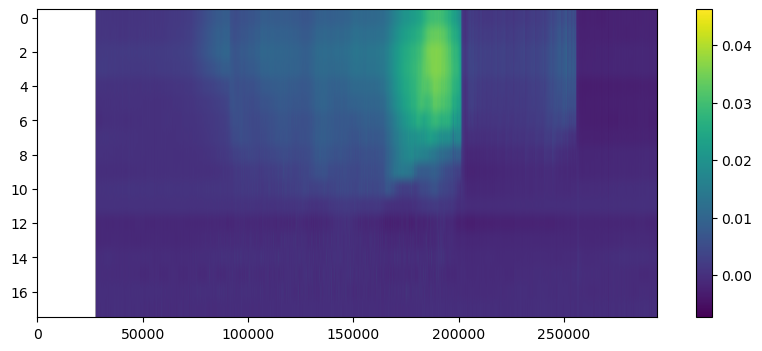

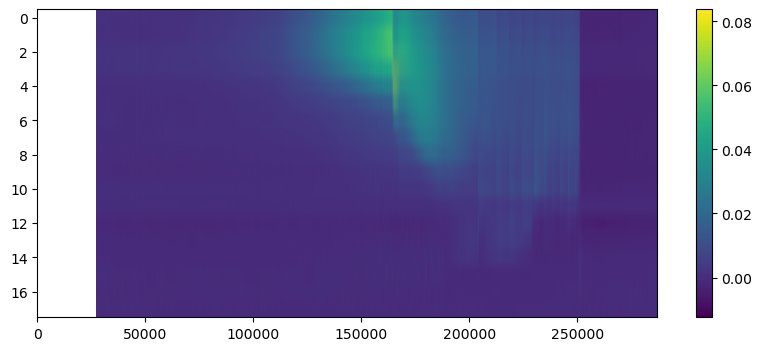

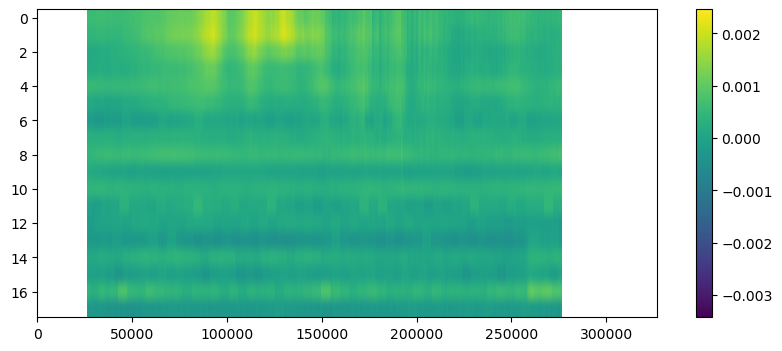

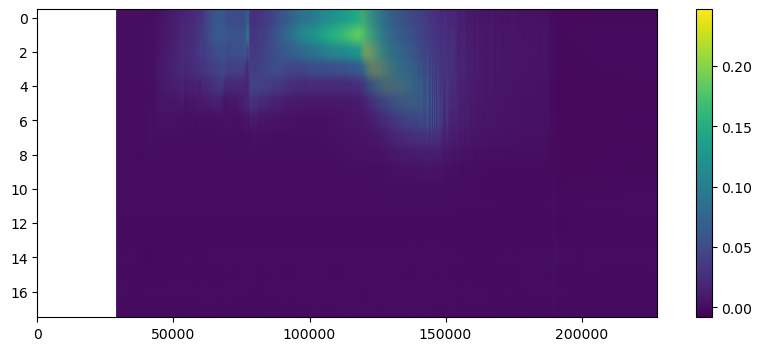

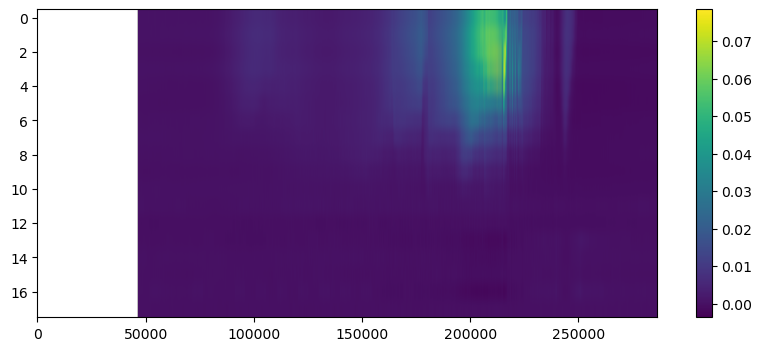

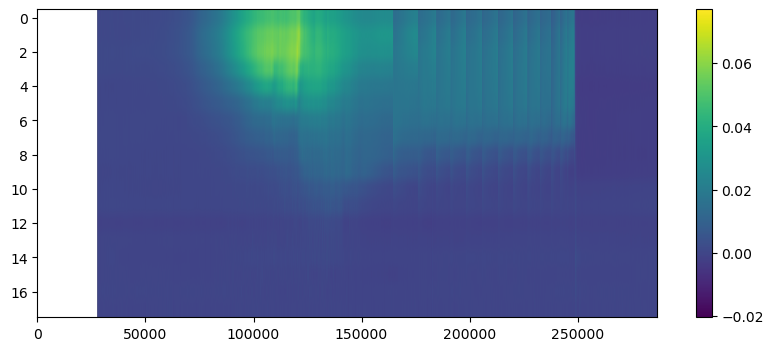

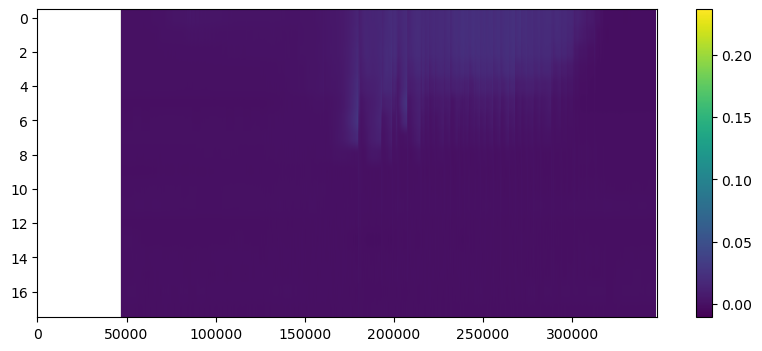

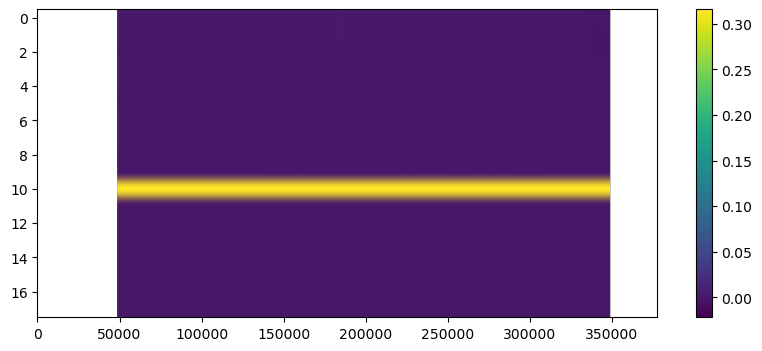

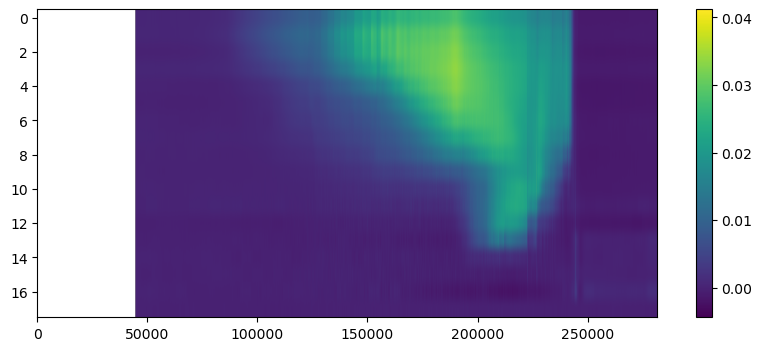

In [63]:
# shot_idx = get_idx(train_MAST_dataset, 29562)

test_MAST_dataset = initialize_MAST_dataset( 
    config_task,
    test_shots_,
    local_flag = local_flag,
    use_std_scaling = False,
    return_incomplete_shots=True
)

for shot_idx in range(0, 10):

    var = 'soft_x_rays-horizontal_cam_lower'
    data = test_MAST_dataset[shot_idx][var]

    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 4))  # width, height in inches

    plt.imshow( data['values'].T[:].T, aspect='auto')
    plt.colorbar()

    plt.show()

In [22]:
train_MAST_dataset

In [ ]:
def get_idx(MAST_dataset, shot_id):
    return(MAST_dataset.shots_list.index(shot_id))

In [43]:
len(train_MAST_dataset.shots_list)

9259

In [45]:
train_MAST_dataset.shots_list.index(19463)

486

In [47]:
get_idx(train_MAST_dataset, 19461)

3279

In [48]:
shot_idx =get_idx(train_MAST_dataset, 19461)
print(shot_idx)
var = 'soft_x_rays-horizontal_cam_upper'

3279


In [52]:
train_MAST_dataset.get_shot_id(3279)

19461

In [ ]:
# shot_idx = get_idx(train_MAST_dataset, 3279)
# print(shot_idx)
# var = 'soft_x_rays-horizontal_cam_upper'
data = test_MAST_dataset[shot_idx][var]

plt.figure(figsize=(10, 4))  # width, height in inches

plt.imshow( data['values'].T[:].T, aspect='auto')
plt.colorbar()

plt.show()

ValueError: 3279 is not in list

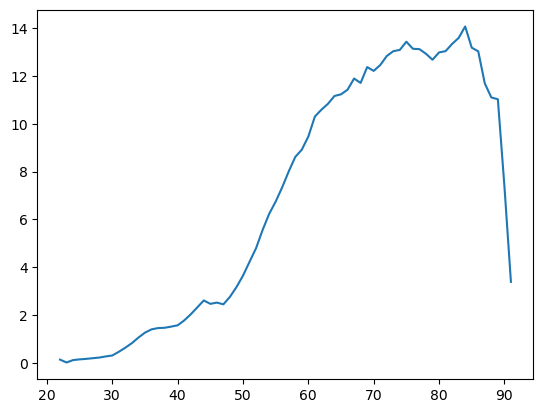

In [30]:
plt.plot( data['values'].T )

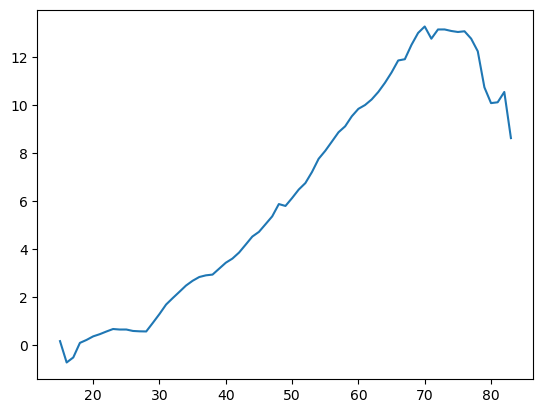

In [32]:
shot_idx = get_idx(test_MAST_dataset, 30428)
# shot_idx = get_idx(test_MAST_dataset, 14497)
var = 'equilibrium-beta_tor'
data = test_MAST_dataset[shot_idx][var]
plt.plot( data['values'].T )

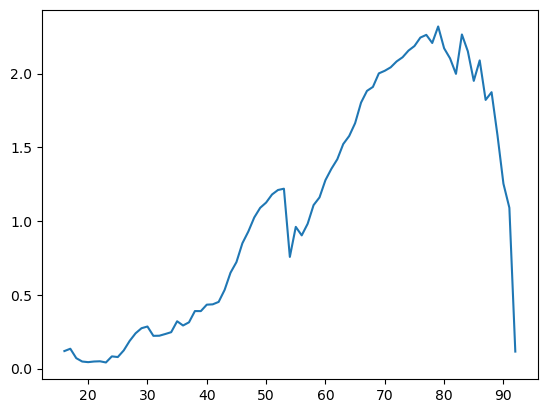

In [33]:
# non problematic

# shot_idx = get_idx(test_MAST_dataset, 30428)
shot_idx = get_idx(test_MAST_dataset, 14497)
var = 'equilibrium-beta_tor'
data = test_MAST_dataset[shot_idx][var]
plt.plot( data['values'].T )

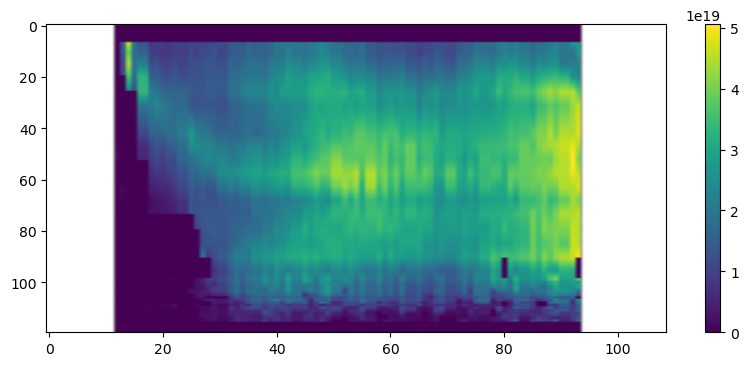

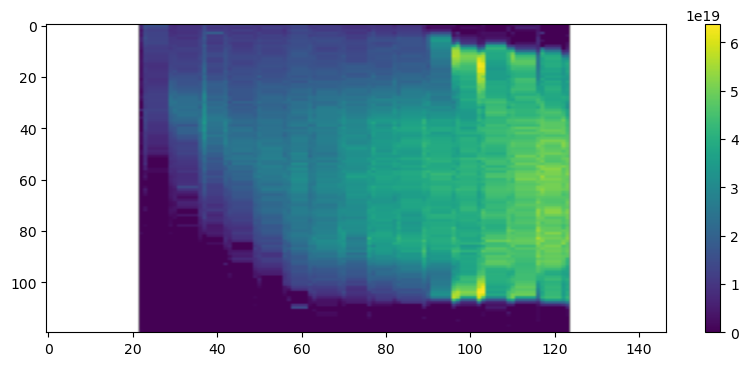

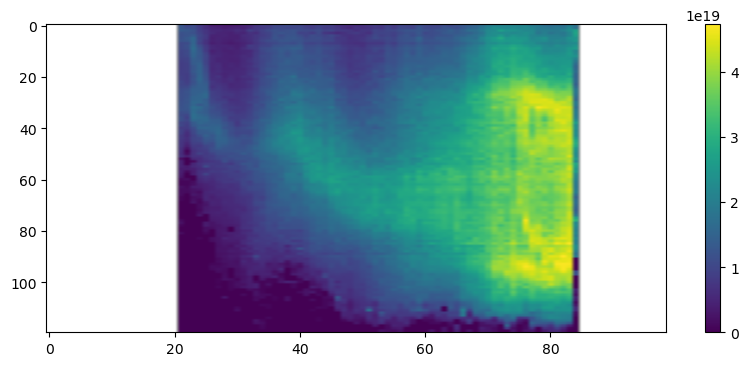

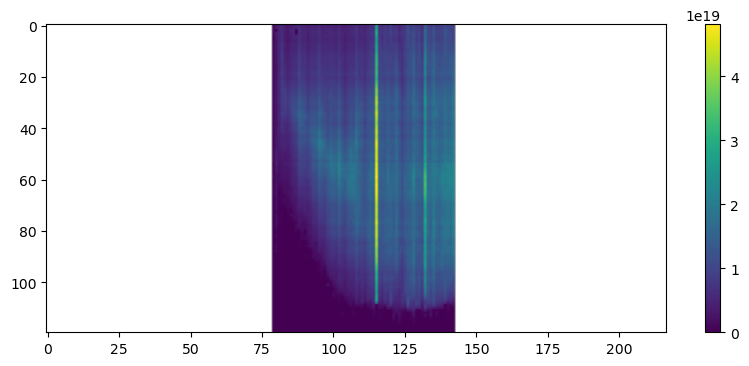

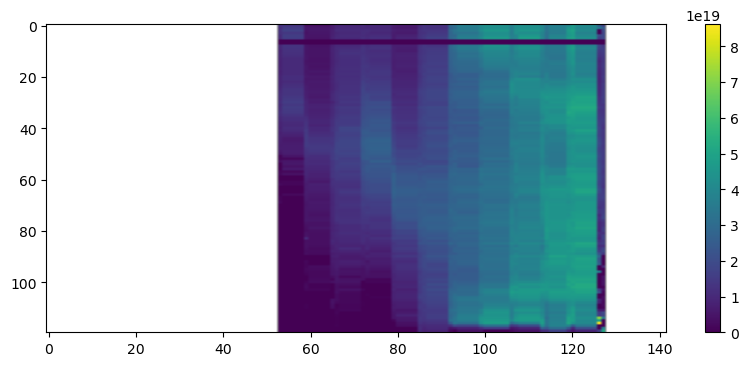

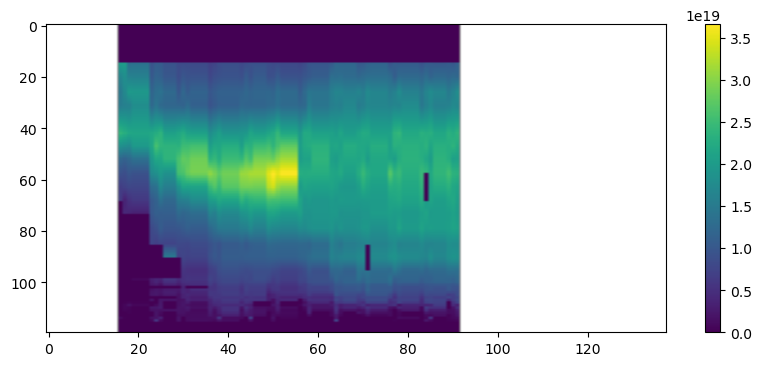

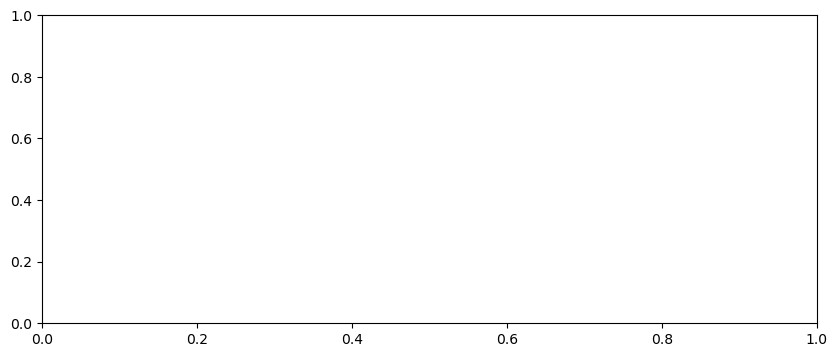

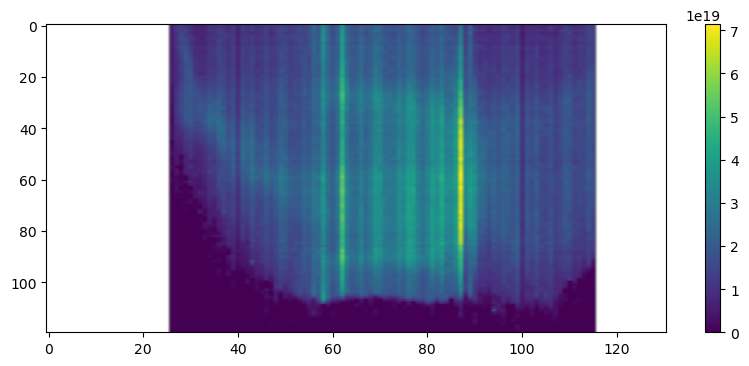

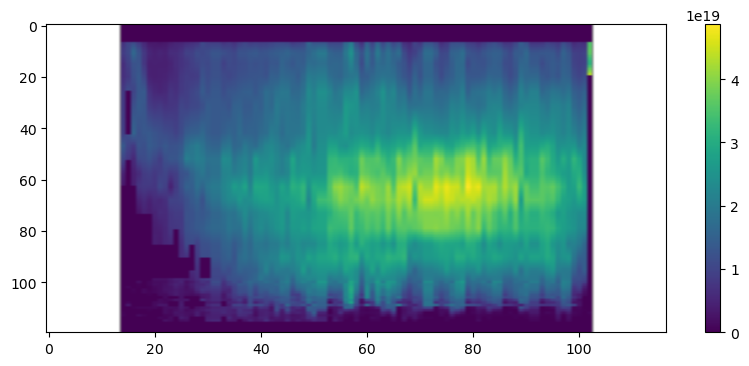

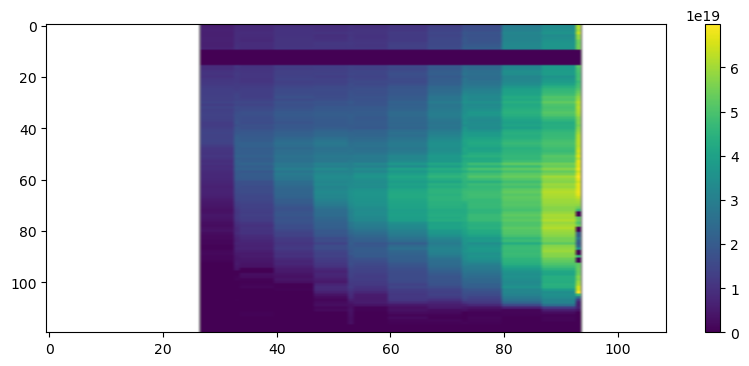

In [ ]:
# Load Task YAML config
config_task = get_task_config("task_3-1")    

# Load CNN YAML config
with open(REPO_ROOT + args.config_cnn, "r") as f:
    config_cnn = yaml.safe_load(f)
    
dict_task_metadata = get_task_metadata(
    config_task,
    verbose=False
)

train_MAST_dataset = initialize_MAST_dataset( 
    config_task,
    train_shots_,
    local_flag = local_flag,
    use_std_scaling = False,
    return_incomplete_shots=True
)

scaled_train_MAST_dataset = initialize_MAST_dataset( 
    config_task,
    train_shots_,
    local_flag = local_flag,
    use_std_scaling = True,
    return_incomplete_shots=True
)

for shot_idx in range(0, 10):

    try:
        var = 'thomson_scattering-n_e'
        data = scaled_train_MAST_dataset[shot_idx][var]
        scaled_data = train_MAST_dataset[shot_idx][var]

        plt.figure(figsize=(10, 4))  # width, height in inches
        plt.imshow( data['values'].T[:].T, aspect='auto')
        plt.imshow( scaled_data['values'].T[:].T, aspect='auto')
        plt.colorbar()

        plt.show()
    
    except:
        continue

In [10]:
1/0.0001


10000.0